Dataset Shape:
(600000, 12)

Subscription Dataset:
(239785, 15)

Total Subscription Spending:
60010352.44

Average Subscription Cost:
250.26733298579978


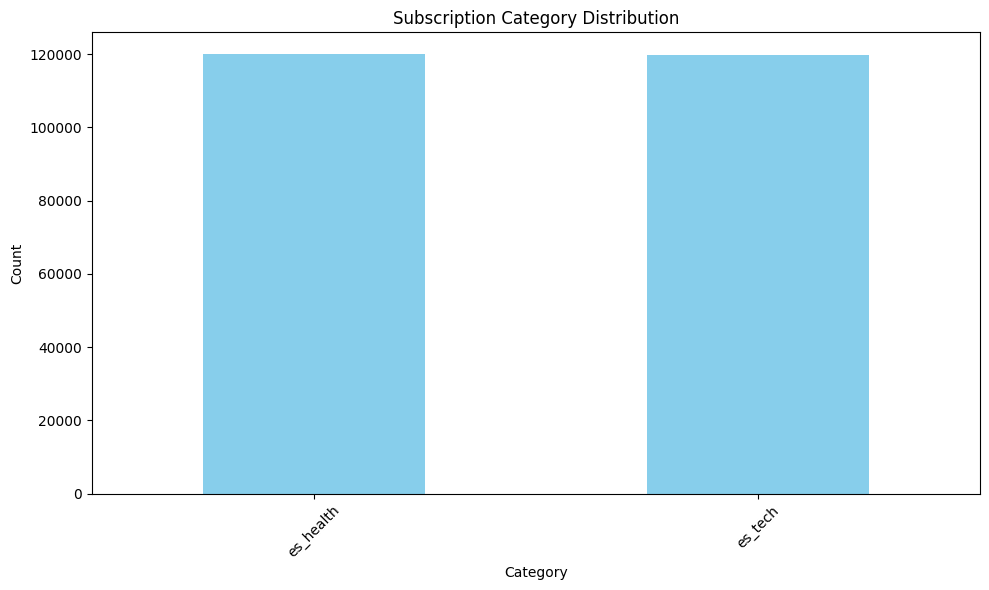

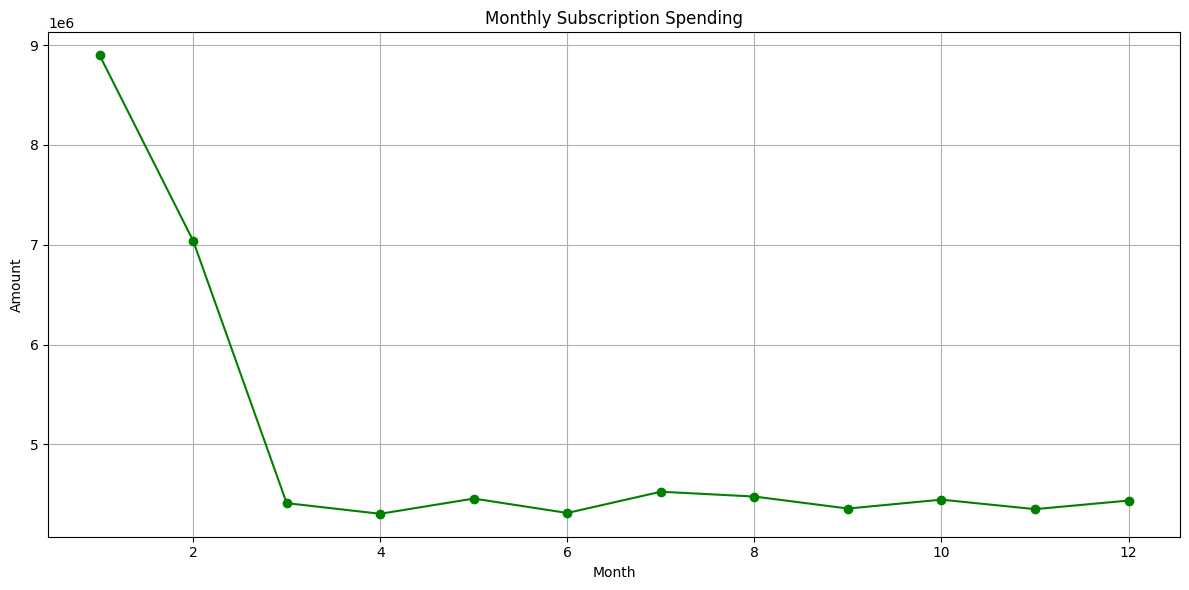


Top Spending Customers:
customer
e08bf4d3-3da4-4dfd-b357-75f939421fa1    500.00
af5fd46a-2eb5-44fa-92bf-7a23b3264e5e    499.99
1d9c8a01-13d9-4235-9d1f-77351abb95fe    499.99
f8beaef9-8032-4d7c-835f-cfb824c52a2b    499.99
aaa9c294-d2f9-4624-a7f7-785abd040e08    499.99
cfca5121-54fa-4174-9ef0-ab8046ea5e39    499.99
b06711d3-8ef8-4d58-8f40-193d5027eba5    499.99
ca352aaa-2a3c-49d0-9ddf-8adde8335d1d    499.98
461857ef-a3ee-4a60-a353-a31a02bc582f    499.98
a1523475-f82f-42a8-8d40-8d3ab413ffe3    499.98
Name: amount, dtype: float64

Top Merchants:
merchant
Smith Inc           77386.92
Smith and Sons      74527.78
Smith Group         74177.03
Smith PLC           74034.60
Smith LLC           73185.18
Smith Ltd           69097.52
Johnson LLC         68251.81
Johnson Ltd         61001.50
Johnson and Sons    59531.73
Johnson Group       58209.84
Name: amount, dtype: float64


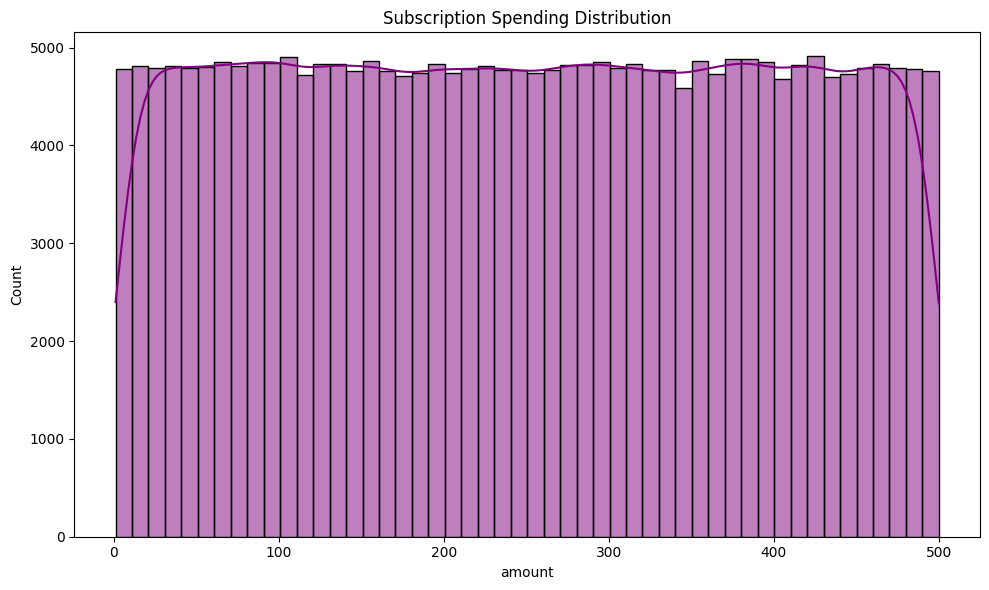

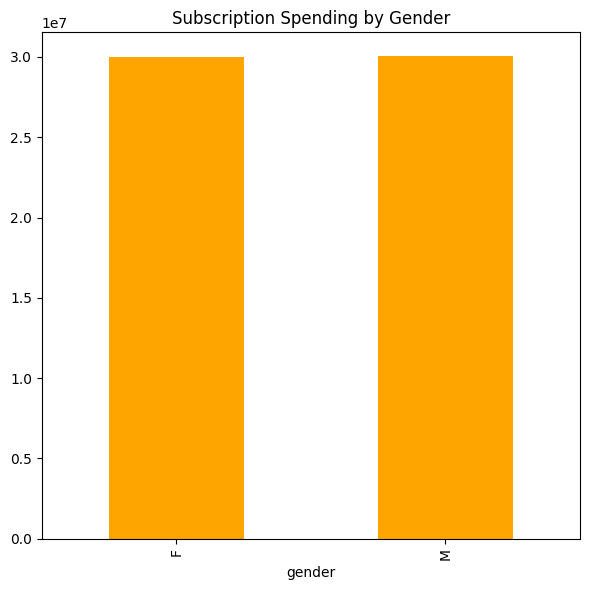

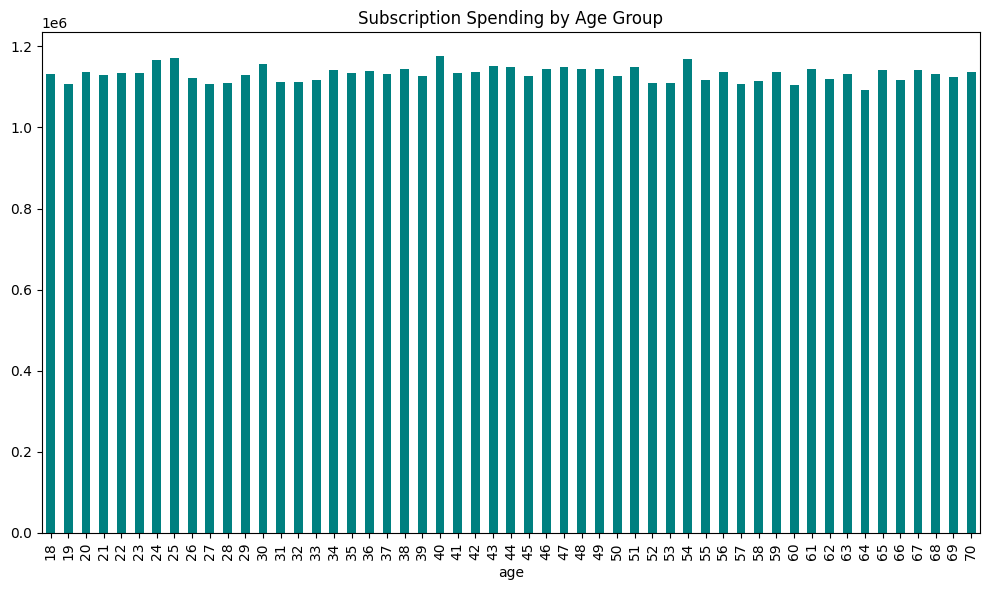

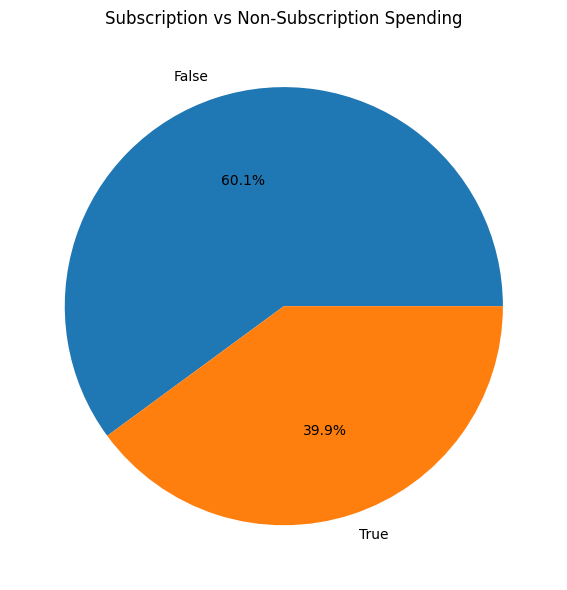


Recurring Payments:
Empty DataFrame
Columns: [customer, merchant, transaction_count]
Index: []

Customer Features:
                               customer  total_spending  average_spending  \
0  00002050-d6aa-460b-9830-2b52f263577a          232.59            232.59   
1  00005168-6c3b-4810-8a7d-53d93316fa45          328.30            328.30   
2  0000556d-d7d9-45b8-bcd4-1c5d72babaa6          214.92            214.92   
3  00005cb6-1c69-4b5e-bd9b-9a2ed791c19c          403.47            403.47   
4  00010027-ed74-4414-876d-a1e81a4bbfcd          153.40            153.40   

   subscription_count  
0                   1  
1                   1  
2                   1  
3                   1  
4                   1  


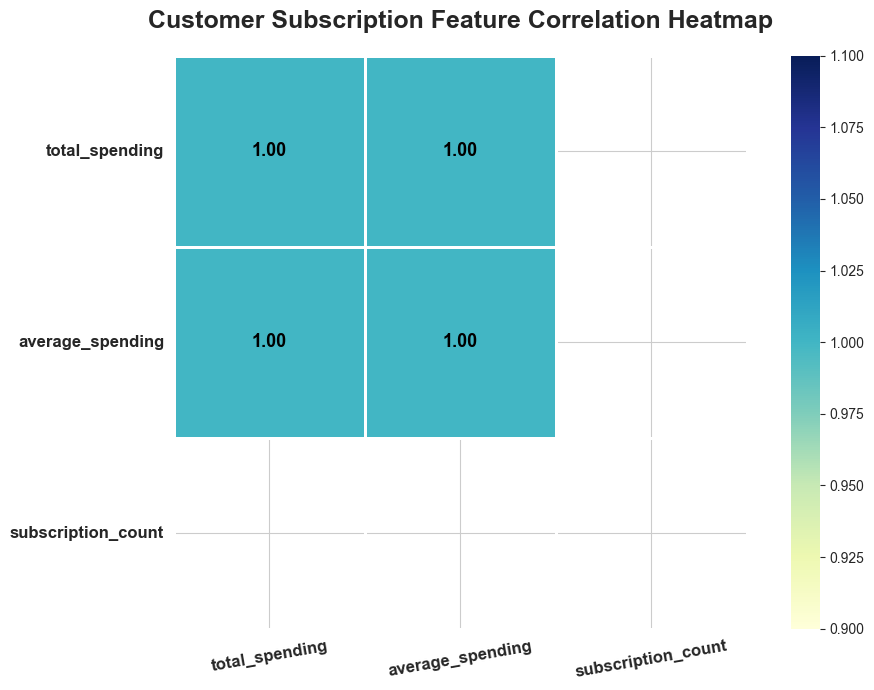


Isolation Forest Results:
isolation_forest_anomaly
0    227795
1     11990
Name: count, dtype: int64

DBSCAN Clusters:
dbscan_cluster
0    5000
Name: count, dtype: int64

Zombie Subscription Detection:
zombie_subscription
1    239785
Name: count, dtype: int64

Overspending Customers:
overspending_flag
0    227798
1     11987
Name: count, dtype: int64


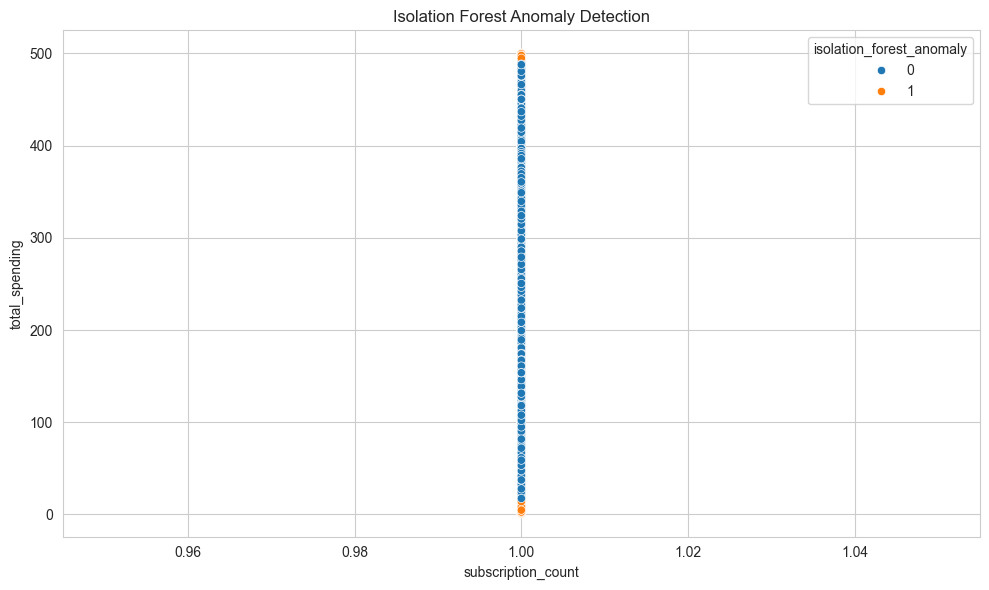


Datasets Exported Successfully

Summary Statistics
       total_spending  average_spending  subscription_count  \
count   239785.000000     239785.000000            239785.0   
mean       250.267333        250.267333                 1.0   
std        144.102817        144.102817                 0.0   
min          1.000000          1.000000                 1.0   
25%        125.350000        125.350000                 1.0   
50%        250.230000        250.230000                 1.0   
75%        375.250000        375.250000                 1.0   
max        500.000000        500.000000                 1.0   

       isolation_forest_anomaly  zombie_subscription  overspending_flag  
count             239785.000000             239785.0      239785.000000  
mean                   0.050003                  1.0           0.049991  
std                    0.217952                  0.0           0.217926  
min                    0.000000                  1.0           0.000000  
25%       

In [1]:
# ============================================================
# SUBSCRIPTION TRAP DETECTOR
# COMPLETE PROJECT PIPELINE
# MSc Data Science Project
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN

# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv(
    "banksim.csv",
    parse_dates=['date'],
    dayfirst=True
)

print("Dataset Shape:")
print(df.shape)

# ============================================================
# 3. DATA CLEANING
# ============================================================

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing categorical values
categorical_cols = [
    'customer',
    'age',
    'gender',
    'merchant',
    'category'
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill missing numerical values
df['amount'] = df['amount'].fillna(df['amount'].median())

# ============================================================
# 4. DATE FEATURES
# ============================================================

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_name'] = df['date'].dt.day_name()

# ============================================================
# 5. SUBSCRIPTION FILTERING
# ============================================================

df['is_subscription'] = df['is_subscription'].astype(bool)

subscription_df = df[df['is_subscription'] == True]

print("\nSubscription Dataset:")
print(subscription_df.shape)

# ============================================================
# PHASE 2 - EXPLORATORY DATA ANALYSIS
# ============================================================

# ============================================================
# 6. TOTAL SUBSCRIPTION SPENDING
# ============================================================

print("\nTotal Subscription Spending:")
print(subscription_df['amount'].sum())

# ============================================================
# 7. AVERAGE SUBSCRIPTION COST
# ============================================================

print("\nAverage Subscription Cost:")
print(subscription_df['amount'].mean())

# ============================================================
# 8. CATEGORY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

subscription_df['category'].value_counts().plot(
    kind='bar',
    color='skyblue'
)

plt.title("Subscription Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ============================================================
# 9. MONTHLY SUBSCRIPTION SPENDING
# ============================================================

monthly_spending = subscription_df.groupby(
    'month'
)['amount'].sum()

plt.figure(figsize=(12,6))

monthly_spending.plot(
    kind='line',
    marker='o',
    color='green'
)

plt.title("Monthly Subscription Spending")
plt.xlabel("Month")
plt.ylabel("Amount")

plt.grid(True)

plt.tight_layout()

plt.show()

# ============================================================
# 10. TOP SPENDING CUSTOMERS
# ============================================================

top_customers = subscription_df.groupby(
    'customer'
)['amount'].sum().sort_values(
    ascending=False
).head(10)

print("\nTop Spending Customers:")
print(top_customers)

# ============================================================
# 11. TOP MERCHANTS
# ============================================================

top_merchants = subscription_df.groupby(
    'merchant'
)['amount'].sum().sort_values(
    ascending=False
).head(10)

print("\nTop Merchants:")
print(top_merchants)

# ============================================================
# 12. SPENDING DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    subscription_df['amount'],
    bins=50,
    kde=True,
    color='purple'
)

plt.title("Subscription Spending Distribution")

plt.tight_layout()

plt.show()

# ============================================================
# 13. SPENDING BY GENDER
# ============================================================

gender_spending = subscription_df.groupby(
    'gender'
)['amount'].sum()

plt.figure(figsize=(6,6))

gender_spending.plot(
    kind='bar',
    color='orange'
)

plt.title("Subscription Spending by Gender")

plt.tight_layout()

plt.show()

# ============================================================
# 14. SPENDING BY AGE
# ============================================================

age_spending = subscription_df.groupby(
    'age'
)['amount'].sum()

plt.figure(figsize=(10,6))

age_spending.plot(
    kind='bar',
    color='teal'
)

plt.title("Subscription Spending by Age Group")

plt.tight_layout()

plt.show()

# ============================================================
# 15. SUBSCRIPTION VS NON-SUBSCRIPTION
# ============================================================

comparison = df.groupby(
    'is_subscription'
)['amount'].sum()

plt.figure(figsize=(6,6))

comparison.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Subscription vs Non-Subscription Spending")

plt.ylabel("")

plt.tight_layout()

plt.show()

# ============================================================
# 16. RECURRING PAYMENT DETECTION
# ============================================================

recurring_payments = subscription_df.groupby(
    ['customer', 'merchant']
).size().reset_index(name='transaction_count')

recurring_payments = recurring_payments[
    recurring_payments['transaction_count'] > 1
]

print("\nRecurring Payments:")
print(recurring_payments.head())

# ============================================================
# PHASE 3 - FEATURE ENGINEERING
# ============================================================

# ============================================================
# 17. MONTHLY SUBSCRIPTION COST
# ============================================================

monthly_customer_spending = subscription_df.groupby(
    ['customer', 'month']
)['amount'].sum().reset_index()

monthly_customer_spending.rename(
    columns={'amount': 'monthly_subscription_cost'},
    inplace=True
)

# ============================================================
# 18. ANNUAL SUBSCRIPTION COST
# ============================================================

annual_customer_spending = subscription_df.groupby(
    ['customer', 'year']
)['amount'].sum().reset_index()

annual_customer_spending.rename(
    columns={'amount': 'annual_subscription_cost'},
    inplace=True
)

# ============================================================
# 19. SUBSCRIPTION COUNT
# ============================================================

subscription_count = subscription_df.groupby(
    'customer'
).size().reset_index(name='subscription_count')

# ============================================================
# 20. AVERAGE SUBSCRIPTION AMOUNT
# ============================================================

avg_subscription_amount = subscription_df.groupby(
    'customer'
)['amount'].mean().reset_index()

avg_subscription_amount.rename(
    columns={'amount': 'avg_subscription_amount'},
    inplace=True
)

# ============================================================
# 21. CUSTOMER FEATURE TABLE
# ============================================================

customer_features = subscription_df.groupby(
    'customer'
).agg({
    'amount': ['sum', 'mean', 'count']
})

customer_features.columns = [
    'total_spending',
    'average_spending',
    'subscription_count'
]

customer_features.reset_index(inplace=True)

print("\nCustomer Features:")
print(customer_features.head())

# ============================================================
# FEATURE CORRELATION HEATMAP
# ============================================================

correlation_matrix = customer_features[
    [
        'total_spending',
        'average_spending',
        'subscription_count'
    ]
].corr()

plt.figure(figsize=(10,7))

sns.set_style("whitegrid")

heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=2,
    linecolor='white',
    square=True,
    cbar=True,
    annot_kws={
        "size": 13,
        "weight": "bold",
        "color": "black"
    }
)

plt.title(
    "Customer Subscription Feature Correlation Heatmap",
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xticks(
    fontsize=12,
    rotation=10,
    fontweight='bold'
)

plt.yticks(
    fontsize=12,
    rotation=0,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

# ============================================================
# PHASE 4 - ANOMALY DETECTION
# ============================================================

# ============================================================
# 22. FEATURE SCALING
# ============================================================

features = customer_features[
    [
        'total_spending',
        'average_spending',
        'subscription_count'
    ]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

# ============================================================
# 23. ISOLATION FOREST
# ============================================================

iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

customer_features['isolation_forest_anomaly'] = iso_forest.fit_predict(
    scaled_features
)

customer_features[
    'isolation_forest_anomaly'
] = customer_features[
    'isolation_forest_anomaly'
].map({
    1: 0,
    -1: 1
})

print("\nIsolation Forest Results:")
print(
    customer_features[
        'isolation_forest_anomaly'
    ].value_counts()
)

# ============================================================
# 24. DBSCAN CLUSTERING
# ============================================================

sample_features = customer_features.sample(
    n=5000,
    random_state=42
)

sample_scaled = scaler.fit_transform(
    sample_features[
        [
            'total_spending',
            'average_spending',
            'subscription_count'
        ]
    ]
)

dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

sample_features['dbscan_cluster'] = dbscan.fit_predict(
    sample_scaled
)

print("\nDBSCAN Clusters:")
print(
    sample_features[
        'dbscan_cluster'
    ].value_counts()
)

# ============================================================
# 25. ZOMBIE SUBSCRIPTION DETECTION
# ============================================================

customer_features['zombie_subscription'] = np.where(
    customer_features['subscription_count'] <= 1,
    1,
    0
)

print("\nZombie Subscription Detection:")
print(
    customer_features[
        'zombie_subscription'
    ].value_counts()
)

# ============================================================
# 26. OVERSPENDING DETECTION
# ============================================================

threshold = customer_features[
    'total_spending'
].quantile(0.95)

customer_features['overspending_flag'] = np.where(
    customer_features['total_spending'] > threshold,
    1,
    0
)

print("\nOverspending Customers:")
print(
    customer_features[
        'overspending_flag'
    ].value_counts()
)

# ============================================================
# 27. ANOMALY VISUALIZATION
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='subscription_count',
    y='total_spending',
    hue='isolation_forest_anomaly',
    data=customer_features
)

plt.title("Isolation Forest Anomaly Detection")

plt.tight_layout()

plt.show()

# ============================================================
# PHASE 5 - EXPORT DATASETS
# ============================================================

subscription_df.to_csv(
    "cleaned_subscription_data.csv",
    index=False
)

customer_features.to_csv(
    "customer_subscription_features.csv",
    index=False
)

print("\nDatasets Exported Successfully")

# ============================================================
# 28. SUMMARY STATISTICS
# ============================================================

print("\nSummary Statistics")
print(customer_features.describe())

# ============================================================
# 29. PROJECT COMPLETE
# ============================================================

print("\nSubscription Trap Detector Pipeline Completed Successfully")